# Setup

In [18]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

from microbench import MicroBench, MBFunctionCall, MBHostInfo, MBPeakMemory, MBReturnValue

from numcompute_stream.io import load_csv
from numcompute_stream.pipeline import Pipeline
from numcompute_stream.preprocessing import MinMaxScaler, OneHotEncoder, SimpleImputer, StandardScaler
from numcompute_stream.tree import DecisionTreeClassifier
from numcompute_stream.ensemble import EnsembleClassifier
from numcompute_stream.stream import StreamTrainer
from numcompute_stream.visualise import compare_models

DATASET_PATH = Path.cwd() / "sample_student_performance.csv"
BENCHMARK_JSONL_PATH = Path.cwd() / "benchmark_results_stream_models_microbench.jsonl"

# Load the dataset using the custom I/O pipeline

In [19]:
data = load_csv(filename=str(DATASET_PATH), dtype=float, skip_header=True)

X = data[:, 1:-1]
y = data[:, -1].astype(int)

NUMERIC_INDEXES = np.array([0, 1, 2, 3, 4])
CATEGORICAL_INDEXES = np.array([5, 6, 7])

print("Dataset shape:", data.shape)
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Missing numeric values:", int(np.isnan(X[:, NUMERIC_INDEXES]).sum()))
print("Class counts:", np.unique(y, return_counts=True))

Dataset shape: (80, 10)
Feature matrix shape: (80, 8)
Target shape: (80,)
Missing numeric values: 10
Class counts: (array([0, 1]), array([40, 40]))


# Combined incremental feature preprocessor

The benchmark uses the same preprocessing flow for both models:

```text
Numeric columns
    -> SimpleImputer.partial_fit()
    -> MinMaxScaler.partial_fit()
    -> StandardScaler.partial_fit()

Categorical columns
    -> OneHotEncoder.partial_fit()

All transformed columns
    -> concatenate into one numeric feature matrix
```

Using the same preprocessor for both models keeps the comparison fair.

In [20]:
class StudentFeaturePreprocessor:
    def __init__(self, numeric_indexes, categorical_indexes):
        self.numeric_indexes = np.asarray(numeric_indexes)
        self.categorical_indexes = np.asarray(categorical_indexes)
        self.imputer = SimpleImputer(strategy='mean', fill_value=0.0)
        self.minmax_scaler = MinMaxScaler()
        self.standard_scaler = StandardScaler()
        self.encoder = OneHotEncoder(handle_unknown='ignore')

    def fit(self, X, y=None):
        self.__init__(self.numeric_indexes, self.categorical_indexes)
        return self.partial_fit(X, y)

    def partial_fit(self, X, y=None):
        numeric = X[:, self.numeric_indexes]
        categorical = X[:, self.categorical_indexes]

        self.imputer.partial_fit(numeric, y)
        numeric_clean = self.imputer.transform(numeric).astype(float)

        self.minmax_scaler.partial_fit(numeric_clean, y)
        self.standard_scaler.partial_fit(numeric_clean, y)
        self.encoder.partial_fit(categorical, y)

        return self

    def transform(self, X):
        numeric = X[:, self.numeric_indexes]
        categorical = X[:, self.categorical_indexes]

        numeric_clean = self.imputer.transform(numeric).astype(float)
        numeric_minmax = self.minmax_scaler.transform(numeric_clean)
        numeric_standard = self.standard_scaler.transform(numeric_clean)
        categorical_encoded = self.encoder.transform(categorical)

        return np.hstack([
            numeric_minmax,
            numeric_standard,
            categorical_encoded,
        ])

# Define the base and ensemble pipelines

In [21]:
def build_tree_pipeline(
    random_state: int,
) -> Pipeline:
    return Pipeline([
        (
            "features",
            StudentFeaturePreprocessor(
                NUMERIC_INDEXES,
                CATEGORICAL_INDEXES,
            ),
        ),
        (
            "model",
            DecisionTreeClassifier(
                max_depth=4,
                min_samples_split=4,
                random_state=random_state,
            ),
        ),
    ])


def build_ensemble_pipeline(
    random_state: int,
) -> Pipeline:
    return Pipeline([
        (
            "features",
            StudentFeaturePreprocessor(
                NUMERIC_INDEXES,
                CATEGORICAL_INDEXES,
            ),
        ),
        (
            "model",
            EnsembleClassifier(
                n_estimators=7,
                max_depth=4,
                min_samples_split=4,
                random_state=random_state,
            ),
        ),
    ])

## Define the streaming scenario

In [22]:
def split_stream(
    X: np.ndarray,
    y: np.ndarray,
    chunk_size: int,
) -> list[
    tuple[np.ndarray, np.ndarray]
]:
    chunks = [
        (X[start:start + chunk_size], y[start:start + chunk_size])
        for start in range(0, len(X), chunk_size)
    ]
    return chunks


def evaluate_stream(
    pipeline: Pipeline,
    chunk_size: int,
) -> dict:
    chunks = split_stream(X, y, chunk_size)
    trainer = StreamTrainer(model=pipeline)
    initial_X, initial_y = chunks[0]
    trainer.fit_chunk(initial_X, initial_y)

    for (incoming_X, incoming_y) in chunks[1:]:
        trainer.score_chunk(incoming_X, incoming_y)
        trainer.fit_chunk(incoming_X, incoming_y)

    logs = trainer.logs
    cumulative_accuracy = [float(log["cumulative_accuracy"]) for log in logs]
    chunk_error_rate = [float(1 - log["chunk_accuracy"]) for log in logs]

    return {
        "chunk_size": int(chunk_size),
        "evaluated_chunks": int(len(logs)),
        "final_cumulative_accuracy": float(cumulative_accuracy[-1]),
        "mean_chunk_error_rate": float(np.mean(chunk_error_rate)),
        "cumulative_accuracy": cumulative_accuracy,
        "chunk_error_rate": chunk_error_rate,
    }

## Configure Microbench

In [23]:
class StreamModelBench(
    MicroBench,
    MBFunctionCall,
    MBReturnValue,
    MBPeakMemory,
    MBHostInfo,
):
    outfile = str(BENCHMARK_JSONL_PATH)

if BENCHMARK_JSONL_PATH.exists():
    BENCHMARK_JSONL_PATH.unlink()

bench = StreamModelBench(experiment="stream-model-comparison", iterations=3, warmup=1)

## Register benchmark functions

In [24]:
@bench
def benchmark_tree_stream(chunk_size: int, random_state: int):
    return evaluate_stream(
        pipeline=build_tree_pipeline(random_state=random_state),
        chunk_size=chunk_size,
    )


@bench
def benchmark_ensemble_stream(chunk_size: int, random_state: int):
    return evaluate_stream(
        pipeline=build_ensemble_pipeline(random_state=random_state),
        chunk_size=chunk_size,
    )

## Execute benchmark scenarios

In [25]:
CHUNK_SIZES = [
    3,
    5,
    8,
    15,
]

RANDOM_STATE = 42

for chunk_size in CHUNK_SIZES:
    benchmark_tree_stream(
        chunk_size=chunk_size,
        random_state=RANDOM_STATE,
    )

    benchmark_ensemble_stream(
        chunk_size=chunk_size,
        random_state=RANDOM_STATE,
    )

print(
    "Microbench JSONL results:",
    BENCHMARK_JSONL_PATH
)

Microbench JSONL results: /Users/vaifathuy/Documents/AU/COMP5004 - Python For ML/Projects/assignment2.2/benchmark/benchmark_results_stream_models_microbench.jsonl


## Extract Microbench results

In [26]:
results_df = bench.get_results(format="df", flat=True)

results_df["mean_duration_ms"] = results_df["call.durations"].apply(
    lambda durations: (float(np.mean(durations)) * 1000)
)

results_df["peak_memory_kb"] = results_df["call.peak_memory_bytes"] / 1024

summary_df = results_df[[
    "call.name",
    "call.kwargs.chunk_size",
    "mean_duration_ms",
    "peak_memory_kb",
    "call.return_value.final_cumulative_accuracy",
    "call.return_value.mean_chunk_error_rate",
]].copy()

summary_df = summary_df.rename(
    columns={
        "call.name": "model_benchmark",
        "call.kwargs.chunk_size": "chunk_size",
        "call.return_value.final_cumulative_accuracy": "final_cumulative_accuracy",
        "call.return_value.mean_chunk_error_rate": "mean_chunk_error_rate"
    }
)

summary_df

,model_benchmark,chunk_size,mean_duration_ms,peak_memory_kb,final_cumulative_accuracy,mean_chunk_error_rate
0,benchmark_tree_stream,3,111.274889,5410.916016,0.688312,0.314103
1,benchmark_ensemble_stream,3,531.292667,5517.292969,0.727273,0.275641
2,benchmark_tree_stream,5,126.625972,5402.083008,0.760000,0.240000
3,benchmark_ensemble_stream,5,510.352361,5515.775391,0.773333,0.226667
4,benchmark_tree_stream,8,103.836833,5399.801758,0.722222,0.277778
5,benchmark_ensemble_stream,8,566.931361,5511.664062,0.750000,0.250000
6,benchmark_tree_stream,15,103.065320,5395.785156,0.800000,0.200000
7,benchmark_ensemble_stream,15,624.414597,5505.394531,0.769231,0.253333


## Compare total streaming runtime by chunk size

The benchmark measures the complete stream processing scenario, including
incremental preprocessing, prediction, scoring, and model updates.

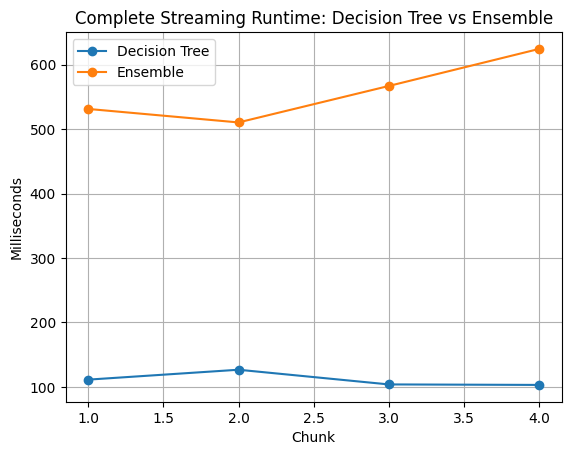

Chunk sizes:  [3, 5, 8, 15]


In [27]:
tree_summary = (
    summary_df[summary_df["model_benchmark"] == "benchmark_tree_stream"].sort_values("chunk_size")
)

ensemble_summary = (
    summary_df[summary_df["model_benchmark"] == "benchmark_ensemble_stream"].sort_values("chunk_size")
)

compare_models(
    metric1=tree_summary["mean_duration_ms"].to_numpy(),
    metric2=ensemble_summary["mean_duration_ms"].to_numpy(),
    labels=[
        "Decision Tree",
        "Ensemble",
    ],
    title=(
        "Complete Streaming Runtime: "
        "Decision Tree vs Ensemble"
    ),
    ylabel="Milliseconds",
)

print("Chunk sizes: ", CHUNK_SIZES)

## Compare predictive quality for one representative stream

The quality curves below use the `chunk_size=8` return values captured by Microbench.

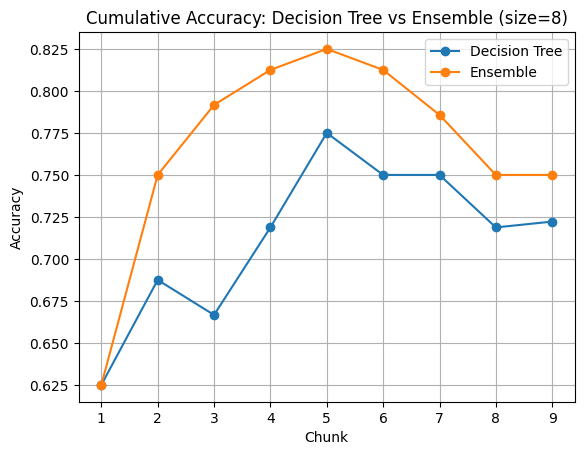

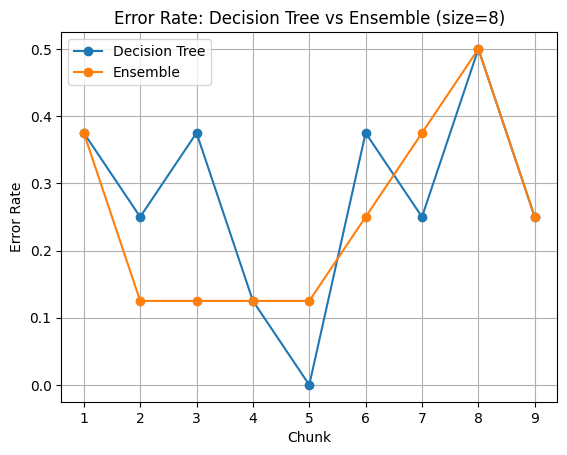

In [32]:
DISPLAY_CHUNK_SIZE = 8

def select_result(
    function_name: str,
    chunk_size: int,
):
    matching_rows = results_df[
        (results_df["call.name"] == function_name)
        & (results_df["call.kwargs.chunk_size"] == chunk_size)
    ]

    return matching_rows.iloc[0]


tree_display = select_result(
    function_name="benchmark_tree_stream",
    chunk_size=DISPLAY_CHUNK_SIZE,
)

ensemble_display = select_result(
    function_name="benchmark_ensemble_stream",
    chunk_size=DISPLAY_CHUNK_SIZE,
)

tree_cumulative_accuracy = np.array(
    tree_display["call.return_value.cumulative_accuracy"]
)

ensemble_cumulative_accuracy = np.array(
    ensemble_display["call.return_value.cumulative_accuracy"]
)

tree_chunk_error_rate = np.array(
    tree_display["call.return_value.chunk_error_rate"]
)

ensemble_chunk_error_rate = np.array(
    ensemble_display["call.return_value.chunk_error_rate"]
)

compare_models(
    metric1=tree_cumulative_accuracy,
    metric2=ensemble_cumulative_accuracy,
    labels=[
        "Decision Tree",
        "Ensemble",
    ],
    title=(
        "Cumulative Accuracy: "
        f"Decision Tree vs Ensemble (size={DISPLAY_CHUNK_SIZE})"
    ),
    ylabel="Accuracy",
)

compare_models(
    metric1=tree_chunk_error_rate,
    metric2=ensemble_chunk_error_rate,
    labels=[
        "Decision Tree",
        "Ensemble",
    ],
    title=(
        "Error Rate: "
        f"Decision Tree vs Ensemble (size={DISPLAY_CHUNK_SIZE})"
    ),
    ylabel="Error Rate",
)